In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.feature_extraction.text import CountVectorizer

In [12]:
# Load Data
DATA_PATH = "../data/raw/dontpatronizeme_pcl.tsv"

rows = []
bad_lines = 0

with open(DATA_PATH, "r", encoding="utf-8", errors="replace") as f:
    for line in f:
        line = line.rstrip("\n")
        parts = line.split("\t")
        if len(parts) == 6:
            rows.append(parts)
        else:
            bad_lines += 1

print("Loaded rows:", len(rows))
print("Bad lines skipped:", bad_lines)

df = pd.DataFrame(rows, columns=[
    "row_id",
    "article_id",
    "keyword",
    "country",
    "paragraph",
    "label_0_4"
])

df.head()

Loaded rows: 10469
Bad lines skipped: 4


,row_id,article_id,keyword,country,paragraph,label_0_4
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0
2,3,@@16584954,immigrant,ie,"""White House press secretary Sean Spicer said ...",0
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0
4,5,@@1494111,refugee,ca,""""""" Just like we received migrants fleeing El ...",0


In [14]:
# Create binary labels 
# 0-1 = No PCL, 2-4 = PCL
df["row_id"] = pd.to_numeric(df["row_id"], errors="coerce")
df["label_0_4"] = pd.to_numeric(df["label_0_4"], errors="coerce")

df = df.dropna(subset=["row_id", "label_0_4"]).copy()

df["row_id"] = df["row_id"].astype(int)
df["label_0_4"] = df["label_0_4"].astype(int)

# Binary mapping: 0-1 = No PCL, 2-4 = PCL
df["label_bin"] = (df["label_0_4"] >= 2).astype(int)

df["label_bin"].value_counts()

label_bin
0    9476
1     993
Name: count, dtype: int64

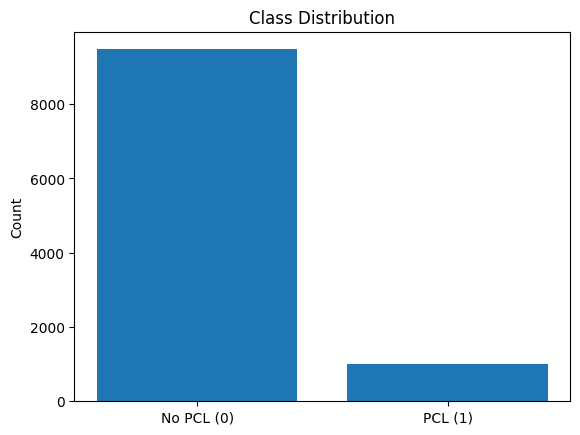

,Class,Count,Percentage
0,No PCL (0),9476,90.514853
1,PCL (1),993,9.485147


In [15]:
# Visual + Table - Statistical Profiling - Class Distribution
class_counts = df["label_bin"].value_counts().sort_index()

plt.bar(["No PCL (0)", "PCL (1)"], class_counts.values)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()

pd.DataFrame({
    "Class": ["No PCL (0)", "PCL (1)"],
    "Count": class_counts.values,
    "Percentage": 100 * class_counts.values / len(df)
})

In [17]:
# Statistical Profiling - Token Count
def simple_tokenize(text):
    return re.findall(r"\b\w+\b", str(text).lower())

df["n_tokens"] = df["paragraph"].apply(lambda x: len(simple_tokenize(x)))

stats = df["n_tokens"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

token_stats_table = pd.DataFrame({
    "Statistic": [
        "Total number of paragraphs",
        "Average tokens per paragraph",
        "Standard deviation",
        "Minimum tokens (shortest paragraph)",
        "Median tokens (50th percentile)",
        "90th percentile (90% are shorter than this)",
        "95th percentile (95% are shorter than this)",
        "99th percentile (99% are shorter than this)",
        "Maximum tokens (longest paragraph)"
    ],
    "Value": [
        int(stats["count"]),
        round(stats["mean"], 2),
        round(stats["std"], 2),
        int(stats["min"]),
        int(stats["50%"]),
        int(stats["90%"]),
        int(stats["95%"]),
        int(stats["99%"]),
        int(stats["max"])
    ]
})

token_stats_table

,Statistic,Value
0,Total number of paragraphs,10469.00
1,Average tokens per paragraph,43.96
2,Standard deviation,26.36
3,Minimum tokens (shortest paragraph),0.00
4,Median tokens (50th percentile),38.00
5,90th percentile (90% are shorter than this),76.00
6,95th percentile (95% are shorter than this),92.00
7,99th percentile (99% are shorter than this),129.00
8,Maximum tokens (longest paragraph),820.00


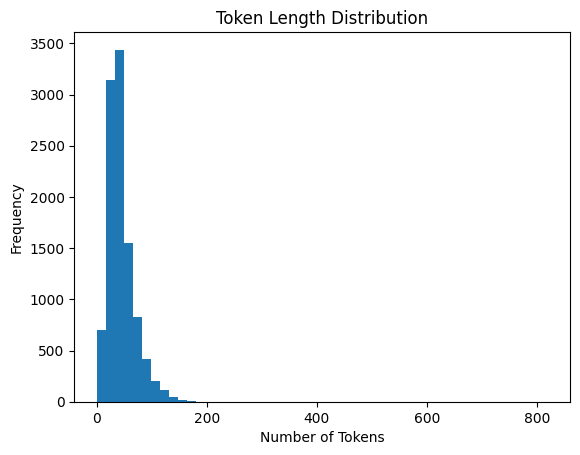

In [18]:
# Visualise
plt.hist(df["n_tokens"], bins=50)
plt.title("Token Length Distribution")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()

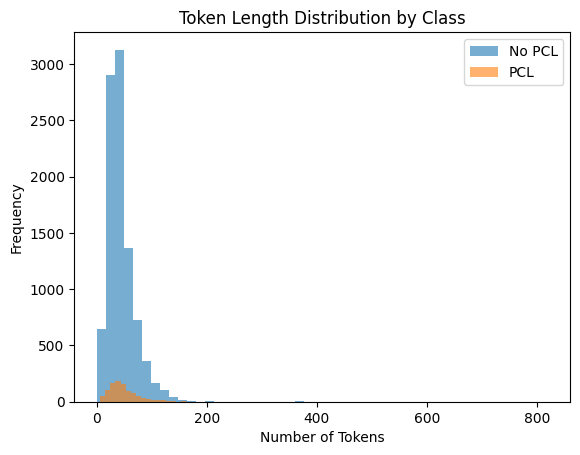

In [19]:
# Token length by class 
plt.hist(df[df["label_bin"] == 0]["n_tokens"], bins=50, alpha=0.6, label="No PCL")
plt.hist(df[df["label_bin"] == 1]["n_tokens"], bins=50, alpha=0.6, label="PCL")
plt.legend()
plt.title("Token Length Distribution by Class")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()

In [20]:
# EDA Technique 2 - Lexical / N-gram Analysis
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=5
)

X = vectorizer.fit_transform(df["paragraph"].fillna(""))
vocab = np.array(vectorizer.get_feature_names_out())

X0 = X[df["label_bin"] == 0]
X1 = X[df["label_bin"] == 1]

freq0 = np.asarray(X0.sum(axis=0)).ravel()
freq1 = np.asarray(X1.sum(axis=0)).ravel()

rate0 = freq0 / X0.shape[0]
rate1 = freq1 / X1.shape[0]

diff = rate1 - rate0

In [21]:
top_idx = np.argsort(-diff)[:15]

top_pcl = pd.DataFrame({
    "ngram": vocab[top_idx],
    "rate_in_PCL": rate1[top_idx],
    "rate_in_NoPCL": rate0[top_idx],
    "difference": diff[top_idx]
})

top_pcl

,ngram,rate_in_PCL,rate_in_NoPCL,difference
0,poor,0.235650,0.100886,0.134763
1,need,0.239678,0.116716,0.122962
2,children,0.200403,0.088645,0.111758
3,families,0.213494,0.119143,0.094351
4,help,0.136959,0.042634,0.094325
5,people,0.258812,0.168109,0.090703
6,homeless,0.178248,0.090545,0.087703
7,life,0.099698,0.026699,0.072999
8,poor families,0.151057,0.081363,0.069694
9,hope,0.065458,0.011186,0.054272


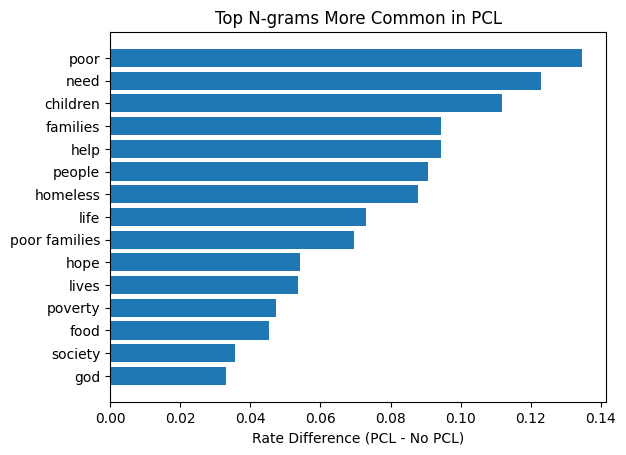

In [22]:
plt.barh(top_pcl["ngram"][::-1], top_pcl["difference"][::-1])
plt.title("Top N-grams More Common in PCL")
plt.xlabel("Rate Difference (PCL - No PCL)")
plt.show()

In [23]:
# Bigram-only lexical analysis

bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2),
    min_df=5
)

X_bigram = bigram_vectorizer.fit_transform(df["paragraph"].fillna(""))
bigram_vocab = np.array(bigram_vectorizer.get_feature_names_out())

X0_big = X_bigram[df["label_bin"] == 0]
X1_big = X_bigram[df["label_bin"] == 1]

freq0_big = np.asarray(X0_big.sum(axis=0)).ravel()
freq1_big = np.asarray(X1_big.sum(axis=0)).ravel()

rate0_big = freq0_big / X0_big.shape[0]
rate1_big = freq1_big / X1_big.shape[0]

diff_big = rate1_big - rate0_big

In [24]:
top_big_idx = np.argsort(-diff_big)[:15]

top_bigrams = pd.DataFrame({
    "bigram": bigram_vocab[top_big_idx],
    "rate_in_PCL": rate1_big[top_big_idx],
    "rate_in_NoPCL": rate0_big[top_big_idx],
    "difference": diff_big[top_big_idx]
})

top_bigrams

,bigram,rate_in_PCL,rate_in_NoPCL,difference
0,poor families,0.151057,0.081363,0.069694
1,people need,0.029204,0.009076,0.020129
2,help need,0.021148,0.002849,0.018299
3,homeless people,0.026183,0.011608,0.014575
4,children poor,0.021148,0.006859,0.014289
5,hope hopeless,0.010070,0.000000,0.010070
6,help people,0.011078,0.001161,0.009917
7,hundreds thousands,0.011078,0.002955,0.008123
8,vulnerable people,0.012085,0.004749,0.007336
9,homeless children,0.008056,0.000844,0.007212


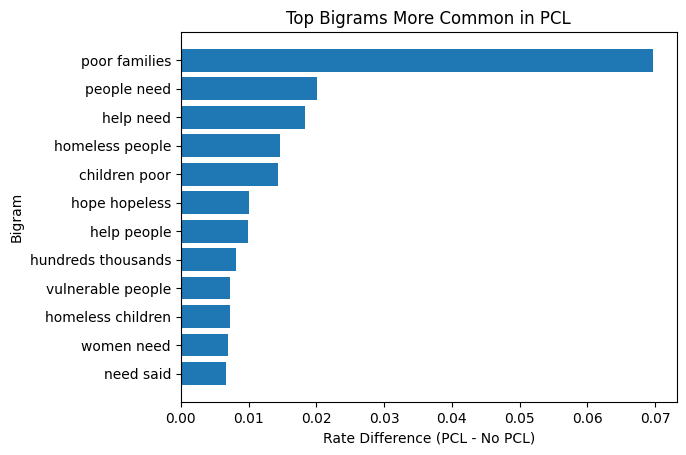

In [27]:
# Visualise top bigrams more common in PCL

top_k = 12

plt.figure()
plt.barh(top_bigrams["bigram"][:top_k][::-1],
         top_bigrams["difference"][:top_k][::-1])

plt.title("Top Bigrams More Common in PCL")
plt.xlabel("Rate Difference (PCL - No PCL)")
plt.ylabel("Bigram")
plt.show()